In [1]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [2]:
dataset_path = "/kaggle/input/datasets"

print(os.listdir(dataset_path))

['jannatulferdaues']


In [3]:
dataset_path = "/kaggle/input/datasets/jannatulferdaues"
print(os.listdir(dataset_path))

['medicinal-flower-dataset']


In [4]:
dataset_path = "/kaggle/input/datasets/jannatulferdaues/medicinal-flower-dataset"

print(os.listdir(dataset_path))

['flower_dataset']


In [5]:
DATASET_PATH = "/kaggle/input/datasets/jannatulferdaues/medicinal-flower-dataset/flower_dataset"

print(os.listdir(DATASET_PATH))

['Sweet_pea', 'Allium_Cepa', 'Black_cumin']


{'Sweet_pea': 1085, 'Allium_Cepa': 855, 'Black_cumin': 1260}


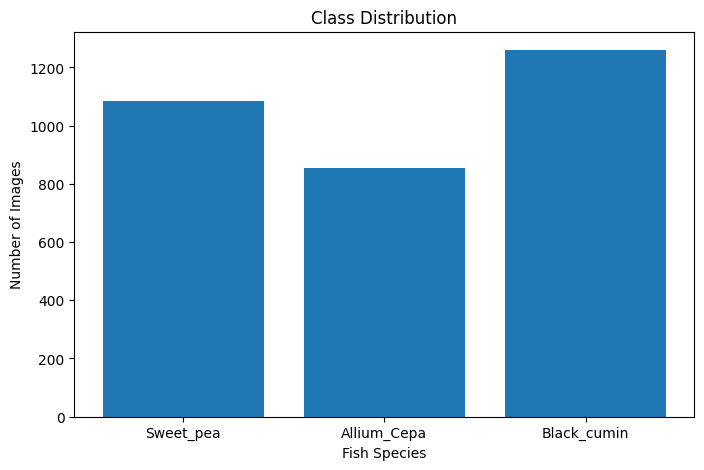

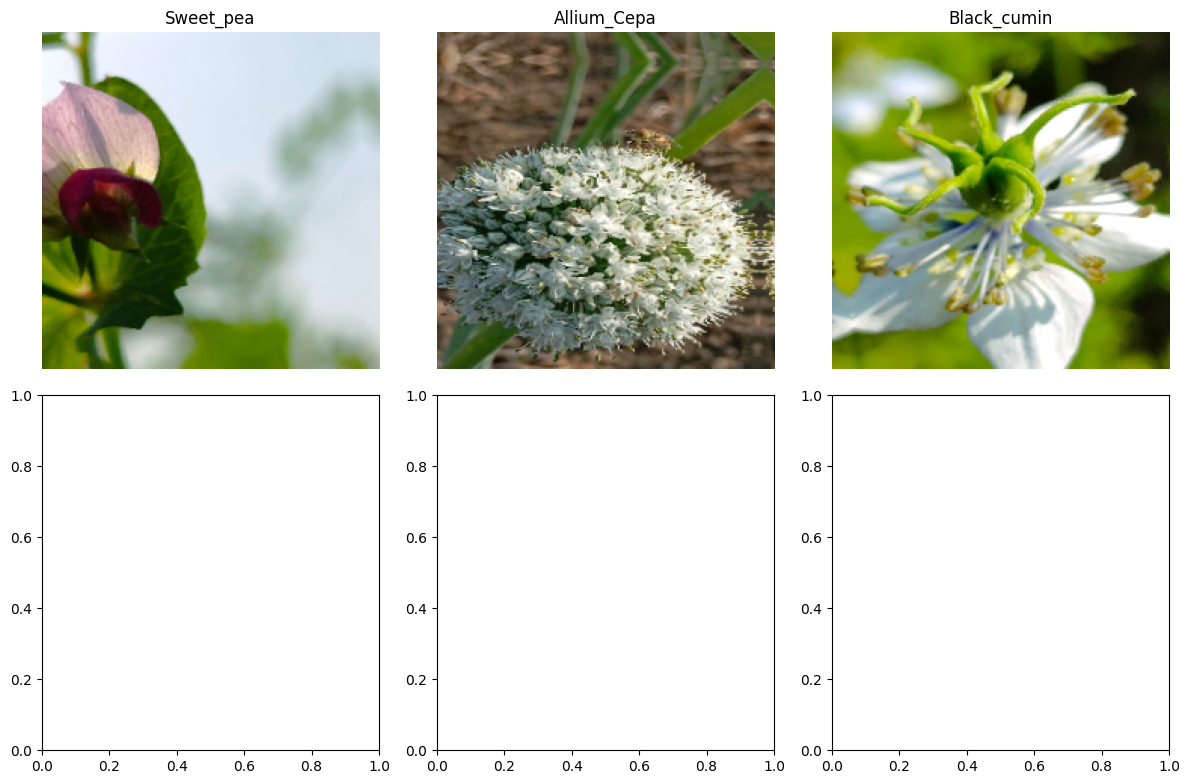

In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

DATASET_PATH = '/kaggle/input/datasets/jannatulferdaues/medicinal-flower-dataset/flower_dataset'

classes = os.listdir(DATASET_PATH)

# Count images
counts = {}
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    counts[cls] = len(os.listdir(cls_path))

print(counts)


plt.figure(figsize=(8,5))
plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.xlabel("Flower Species")
plt.ylabel("Number of Images")
plt.show()


fig, axes = plt.subplots(2,3, figsize=(12,8))

for ax, cls in zip(axes.flatten(), classes):
    img_path = os.path.join(
        DATASET_PATH,
        cls,
        os.listdir(os.path.join(DATASET_PATH, cls))[0]
    )

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf

dataset_base_path = "/kaggle/input/datasets/jannatulferdaues/medicinal-flower-dataset/flower_dataset"

validation_split_ratio = 0.15
test_split_ratio = 0.05
seed_value = 123 # For reproducibility

# Calculate the total fraction of data to be used for validation and testing combined
total_val_test_split_fraction = validation_split_ratio + test_split_ratio

# Create the training dataset. It will use (1 - total_val_test_split_fraction) of the data.
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_base_path,
    validation_split=total_val_test_split_fraction,
    subset="training",
    seed=seed_value,
    image_size=(224,224),
    batch_size=32
)

# Create a combined dataset for validation and testing. It will use total_val_test_split_fraction of the data.
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_base_path,
    validation_split=total_val_test_split_fraction,
    subset="validation",
    seed=seed_value,
    image_size=(224,224),
    batch_size=32
)

# Determine the number of batches for the actual validation and test sets
# within the combined val_test_ds.
# We want validation_split_ratio / total_val_test_split_fraction of val_test_ds for validation,
# and test_split_ratio / total_val_test_split_fraction of val_test_ds for testing.

if total_val_test_split_fraction > 0:
    val_fraction_of_combined = validation_split_ratio / total_val_test_split_fraction
else:
    val_fraction_of_combined = 0 # Should not happen if validation_split_ratio or test_split_ratio is > 0

num_val_test_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
num_val_batches = int(num_val_test_batches * val_fraction_of_combined)

# Split the combined val_test_ds into actual validation and test datasets
val_ds = val_test_ds.take(num_val_batches)
test_ds = val_test_ds.skip(num_val_batches)

# Optional: Cache and prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3200 files belonging to 3 classes.
Using 2560 files for training.
Found 3200 files belonging to 3 classes.
Using 640 files for validation.


In [9]:
!pip install ultralytics
!pip install tensorflow scikit-learn seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.8 MB/s eta 0:00:00


# ==========================================
# Kaggle version of densenet121.py
# ==========================================

In [ ]:
# ==========================================
# Kaggle version of densenet121.py
# ==========================================

# Install required library
!pip install -q python-docx

# Imports
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from docx import Document
from docx.shared import Inches

# ==========================================
# Paths
# ==========================================

# Change only the dataset folder name if necessary
input_path = "/kaggle/input/datasets/jannatulferdaues/medicinal-flower-dataset/flower_dataset"
output_path = "/kaggle/working/Densenet"

os.makedirs(output_path, exist_ok=True)

# Parameters
EPOCHS = 25
BATCH_SIZE = 32
LEARNING_RATE = 0.0000001

# Create Document
doc = Document()
doc.add_heading("Classification Report for DenseNet121", 0)

# ==========================================
# DenseNet121 model builder
# ==========================================

def create_densenet_model(input_shape, num_classes):

    if num_classes == 0:
        raise ValueError("Number of classes cannot be zero. Check dataset generation.")

    base_model = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Fine-tuning last 50 layers
    for layer in base_model.layers[:-50]:
        layer.trainable = False

    for layer in base_model.layers[-50:]:
        layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(2048, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    return model

# ==========================================
# Data pipeline
# ==========================================

def process_data(input_path, img_size, batch_size):

    datagen = ImageDataGenerator(
        preprocessing_function=tf.keras.applications.densenet.preprocess_input,
        validation_split=0.2,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode="nearest",
        brightness_range=[0.8, 1.2],
        channel_shift_range=20.0
    )

    train_gen = datagen.flow_from_directory(
        input_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        subset="training",
        shuffle=True
    )

    val_gen = datagen.flow_from_directory(
        input_path,
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        subset="validation",
        shuffle=False
    )

    return train_gen, val_gen

# ==========================================
# Image size
# ==========================================

img_size = (224, 224)

# Prepare data
train_gen, val_gen = process_data(input_path, img_size, BATCH_SIZE)

# Create model
model = create_densenet_model(
    (img_size[0], img_size[1], 3),
    train_gen.num_classes
)

# Compile
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================================
# Callbacks
# ==========================================

checkpoint = ModelCheckpoint(
    os.path.join(output_path, "DenseNet121_best_model.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# ==========================================
# Training
# ==========================================

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[checkpoint, reduce_lr]
)

# ==========================================
# Fine-Tuning (optional)
# ==========================================

# base_model.trainable = True

# for layer in base_model.layers[:-30]:
#     layer.trainable = False

# model.compile(
#     optimizer=Adam(learning_rate=LEARNING_RATE * 10),
#     loss="categorical_crossentropy",
#     metrics=["accuracy"]
# )

# fine_tune_epochs = 10

# model.fit(
#     train_gen,
#     epochs=fine_tune_epochs,
#     validation_data=val_gen,
#     callbacks=[checkpoint, reduce_lr]
# )

# ==========================================
# Accuracy & Loss Plots
# ==========================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy", marker="o")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", marker="o")
plt.title("DenseNet121 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss", marker="o")
plt.plot(history.history["val_loss"], label="Validation Loss", marker="o")
plt.title("DenseNet121 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

acc_loss_path = os.path.join(
    output_path,
    "DenseNet121_accuracy_loss_curve.png"
)

plt.savefig(acc_loss_path)
plt.close()

# ==========================================
# Evaluation & Predictions
# ==========================================

model = load_model(
    os.path.join(output_path, "DenseNet121_best_model.keras")
)

eval_result = model.evaluate(val_gen)

Y_pred = model.predict(val_gen)

y_pred = np.argmax(Y_pred, axis=1)

y_true = val_gen.classes

report = classification_report(
    y_true,
    y_pred,
    target_names=list(train_gen.class_indices.keys())
)

# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_true, y_pred)

cm_path = os.path.join(
    output_path,
    "DenseNet121_confusion_matrix.png"
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_gen.class_indices.keys(),
    yticklabels=train_gen.class_indices.keys(),
    annot_kws={"size": 14}
)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("Actual", fontsize=14)
plt.title("DenseNet121 Confusion Matrix", fontsize=16)
plt.tight_layout()

plt.savefig(cm_path)
plt.close()

# ==========================================
# Word Report
# ==========================================

doc.add_heading("DenseNet121 Performance", level=1)
doc.add_paragraph(f"Final Validation Loss: {eval_result[0]:.4f}")
doc.add_paragraph(f"Final Validation Accuracy: {eval_result[1]:.4f}")

doc.add_heading("Classification Report", level=2)
doc.add_paragraph(report)

doc.add_heading("Training Accuracy and Loss", level=2)
doc.add_picture(acc_loss_path, width=Inches(6))

doc.add_heading("Confusion Matrix", level=2)
doc.add_picture(cm_path, width=Inches(6))

doc.save(
    os.path.join(
        output_path,
        "DenseNet121_classification_report.docx"
    )
)

print("✅ DenseNet121 model training and report generation completed!")

print("\nFiles saved to:")
print(output_path)

Found 2560 images belonging to 3 classes.
Found 640 images belonging to 3 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/25
